# Optimization Methods

Pablo Winant

In this tutorial you will learn to code and use common optimization
algorithms for static models.

------------------------------------------------------------------------

## Profit optimization by a monopolist

A monopolist produces quantity $q$ of goods X at price $p$. Its cost
function is $c(q) = 0.5 + q (1-qe^{-q})$

The consumer’s demand for price $p$ is $x(p)=2 e^{-0.5 p}$ (constant
elasticity of demand to price).

1.  **Write down the profit function of the monopolist and find the
    optimal production (if any). Don’t use any library except for
    plotting.**

In [18]:
c(q) = 0.5 + q*(1-q*exp(-q))
x(p) = 2*exp(-0.5p)
π(p) = p*x(p) - c(x(p))
# π(p::Vector) = ...
# π(p) = let xx = x(p) ; p*xx - x(xx) end


π (generic function with 1 method)

In [8]:
using Plots

In [27]:
pvec = 0.1:0.01:4 # this is a range (an iterable)
# in case we want a vector we can do
pvec_ = [pvec...];

In [32]:
# [π(p) for p in pvec]
# equivalent to vectorized call
πvec = π.(pvec);

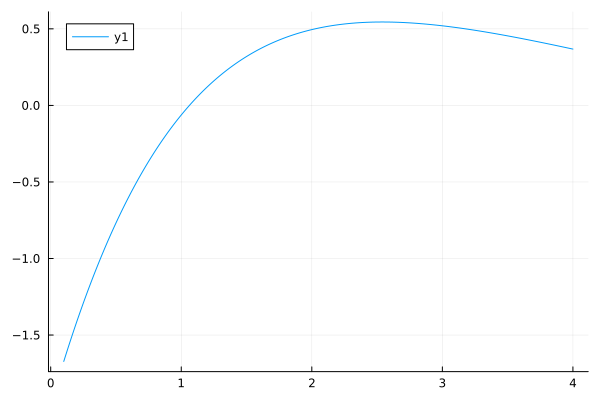

In [29]:
plot(pvec, πvec)

In [34]:
# let's look a the index of the maximized profit

i_max = argmax(πvec)
p_max = pvec[i_max]

2.54

In [ ]:
pvec = range(;start=0.1, stop=4.0, length=100000)


2.539301728339302

In [ ]:
πvec = π.(pvec);
i_max = argmax(πvec)
p_max = pvec[i_max]

In [ ]:
# this version allocates much less memory (no construction of πvec)
@time argmax( (π(p) for p in pvec) )

 15.184407 seconds (205.79 k allocations: 9.831 MiB, 0.24% compilation time)


625461982

In [48]:
# Let's try Newton Raphson
# we need π' and π''

c1(q) = (1-q*exp(-q)) + q*(q*exp(-q) + -exp(-q))
x1(p) = -exp(-0.5p)
π1(p) = x(p) + p*x1(p) - c1(x(p))*x1(p)

π1 (generic function with 1 method)

In [52]:
π1(0.2)

2.4825253505808935

In [53]:
using ForwardDiff
π1(p) = ForwardDiff.derivative(π, p)
π2(p) = ForwardDiff.derivative(π1, p)

π2 (generic function with 1 method)

In [55]:
f(p) = (π(p), π1(p), π2(p))

f (generic function with 1 method)

In [59]:
f(0.10)

(-1.6722012721418804, 2.7322286500588673, -2.5860651404210704)

In [82]:
"""Maximizes  function f"""
function newton_raphson(fun, x0; T=100, τ_η = 1e-10, verbose=false)
    
    
    fun1(p) = ForwardDiff.derivative(fun, p)
    fun2(p) = ForwardDiff.derivative(fun1, p)
    
    f(p) = (fun(p), fun1(p), fun2(p))

    for t=1:T
        # evaluate function derivatives
        (_, f1, f2) = f(x0)
        # apply Newton Raphson step
        x1 = x0 - f1/f2
        # compute successive approximation errors
        η = abs(x1-x0)

        #optionnally print iterations
        verbose ? println("$t: $η") : nothing
        
        # check convergence:
        if η < τ_η
            return x1
        end
        # update the guess
        x0 = x1
    end

    error("Algorithm didn't converge after $T iterations.")

end

newton_raphson

In [73]:
@time newton_raphson(f, 0.5)

  0.000003 seconds


2.539301752872053

In [63]:
?newton_raphson

search: newton_raphson



Maximizes twice-differentiable function f


In [ ]:
newton_raphson(
    u->log(1+u)*exp(-u),
    1.0
    )

0.7632228343518966

------------------------------------------------------------------------

## Constrained optimization

Consider the function $f(x,y) = 1-(x-0.5)^2 -(y-0.3)^2$.

1.  **Use Optim.jl to maximize $f$ without constraint. Check you
    understand diagnostic information returned by the optimizer.**

In [26]:
import Pkg
Pkg.activate("../..")

  Activating project at `~/Teaching/econobits`


In [27]:
using Optim

In [ ]:
f(x,y)  = 1- (x-0.5)^2 - (y-0.3)^2


f (generic function with 3 methods)

In [29]:
# reformulate the function to maximize as a function of vectors
f(u::Vector{Float64}) = f(u[1],u[2])

f (generic function with 3 methods)

In [30]:
x0 = [0.1, 0.2]
res = optimize(u -> -f(u), x0)

 * Status: success

 * Candidate solution
    Final objective value:     -1.000000e+00

 * Found with
    Algorithm:     Nelder-Mead

 * Convergence measures
    √(Σ(yᵢ-ȳ)²)/n ≤ 1.0e-08

 * Work counters
    Seconds run:   0  (vs limit Inf)
    Iterations:    28
    f(x) calls:    56


In [31]:
res.minimizer

2-element Vector{Float64}:
 0.49993816060911933
 0.3000756301799443

In [32]:
# let's get some intuition
using Plots

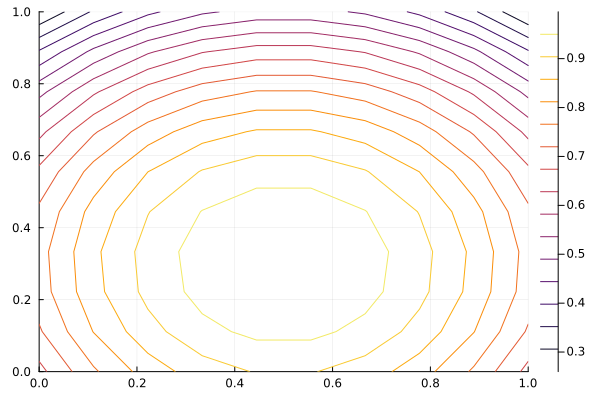

In [33]:
pl = contour( range(0,1;length=10), range(0,1; length=10), f)

1.  **Now, consider the constraint $x<=0.3$ and maximize $f$ under this
    new constraint.**

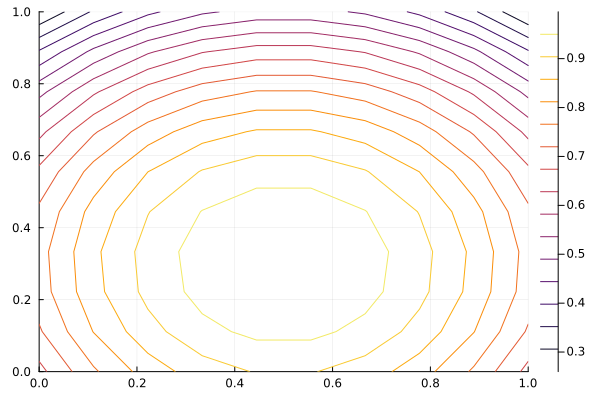

In [34]:
pl = contour( range(0,1;length=10), range(0,1; length=10), f)
vline!(pl,x=0.3)
pl

In [54]:
g(x,y) = [
    -2*(x-0.5), # diff wr.t. x
    -2*(y-0.3) # diff w.r.t y
]
g(u) = g(u[1], u[2])

function ng!(r, u) # excalatmation mark: function mutates its (first) argument
    # NOT: r = g(u) # would change the value of r
    r[:] = -g(u) # assigns values in r
    
end


ng! (generic function with 1 method)

In [58]:
inner_optimizer = GradientDescent()
res = optimize(u->-f(u), ng!, [-Inf,-Inf], [0.3, Inf], [0.0, 0.0], Fminbox(inner_optimizer))
res.minimizer

2-element Vector{Float64}:
 0.2999999988
 0.3000000000001103

1.  **Reformulate the problem as a root finding problem with
    lagrangians. Write the complementarity conditions.**

In [59]:
min_FB(a,b) = (a+b - sqrt(a^2+b^2))/2

min_FB (generic function with 1 method)

In [64]:
function fun(x,y,l)
    [
        -2(x-0.5) - l,
        -2(y-0.3),
        min_FB(l, 0.3-x)
    ]
end
fun(u) = fun(u...)

fun (generic function with 2 methods)

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [0.0, 0.0, 0.0]
 * Zero: [0.30000000006391536, 0.3, 0.3999999998721692]
 * Inf-norm of residuals: 0.000000
 * Iterations: 5
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 6
 * Jacobian Calls (df/dx): 6

1.  **Solve using NLsolve.jl**

In [66]:
using NLsolve
nlsolve(fun, [0.0, 0.0, 0.0])

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [0.0, 0.0, 0.0]
 * Zero: [0.30000000006391536, 0.3, 0.3999999998721692]
 * Inf-norm of residuals: 0.000000
 * Iterations: 5
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 6
 * Jacobian Calls (df/dx): 6

------------------------------------------------------------------------

## Consumption optimization

A consumer has preferences $U(c_1, c_2)$ over two consumption goods
$c_1$ and $c_2$.

Given a budget $I$, consumer wants to maximize utility subject to the
budget constraint $p_1 c_1 + p_2 c_2 \leq I$.

We choose a Stone-Geary specification where

$U(c_1, c_2)=\beta_1 \log(c_1-\gamma_1) + \beta_2 \log(c_2-\gamma_2)$

1.  **Write the Karush-Kuhn-Tucker necessary conditions for the
    problem.**

In [7]:
# your code here

1.  **Verify the KKT conditions are sufficient for optimality.**

In [8]:
# your code here

1.  **Derive analytically the demand functions, and the shadow price.**

In [9]:
# your code here

1.  **Interpret this problem as a complementarity problem and solve it
    using NLSolve.**

In [10]:
# your code here

1.  **Produce some nice graphs with isoutility curves, the budget
    constraint and the optimal choice.**

In [11]:
# your code here